In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import glob

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

In [5]:
DATASET_DIR = Path('./test')  # adjust if needed

files = sorted(glob.glob(str(DATASET_DIR / 'trajectory_*.json')))
print(f'Found {len(files)} trajectory files')

trajectories = []
for f in files:
    with open(f) as fh:
        trajectories.append(json.load(fh))

print(f'Loaded {len(trajectories)} trajectories')

Found 600 trajectory files
Loaded 600 trajectories


## Example ECRH and NBI schedules

Shows the heating schedule for a single trajectory, linearly interpolated between applied points. The shaded region marks where the agent has control (t = 100 to 500 s). The ramp-up (0–80 s) and ramp-down (520–600 s) are fixed.

Best trajectory: run_id=148, Q_flattop_avg=4.590


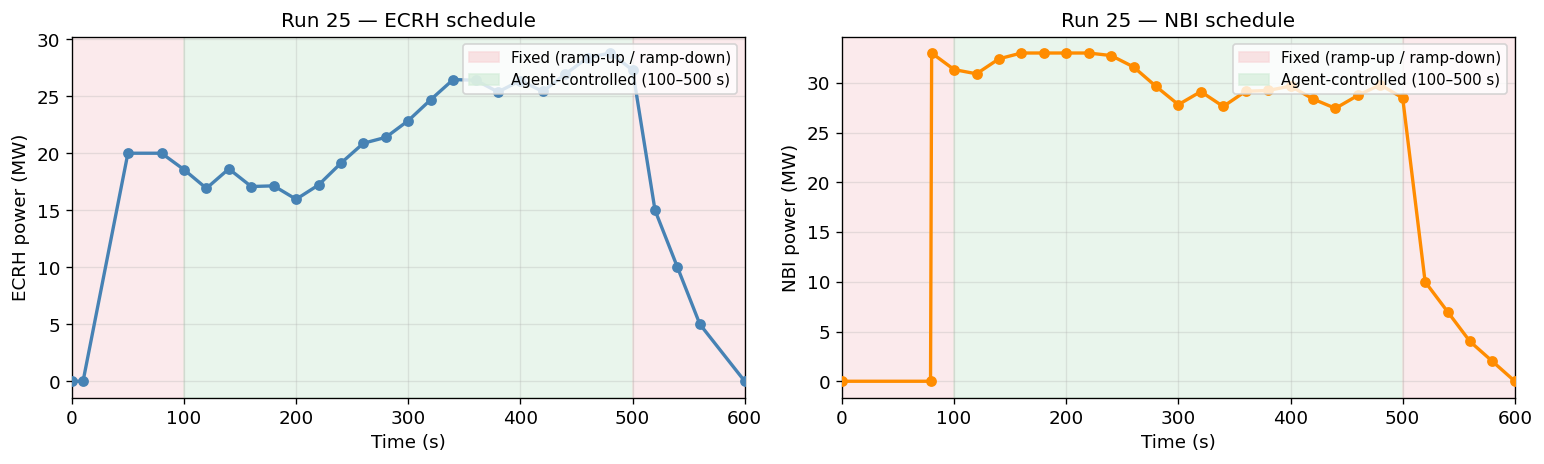

In [6]:
def reconstruct_schedules(traj):
    """
    Reconstruct the ECRH and NBI schedules from a trajectory.
    
    The stored action a[i] = [ecrh_W, nbi_W] is the value that was written
    at t_apply = t + 20, so decision at t=80 applies at t=100, etc.
    
    Fixed ramp-up and ramp-down points are added explicitly.
    Returns (times, ecrh_W, nbi_W) as sorted arrays for linear interpolation.
    """
    # Fixed ramp-up points (W)
    ecrh_fixed_up = {0: 0, 10: 0, 50: 20e6, 80: 20e6}
    nbi_fixed_up  = {0: 0, 79: 0, 80: 33e6}

    # Fixed ramp-down points (W)
    ecrh_fixed_down = {520: 15e6, 540: 10e6, 560: 5e6, 600: 0}
    nbi_fixed_down  = {520: 10e6, 540: 7e6, 560: 4e6, 580: 2e6, 600: 0}

    ecrh_sched = dict(ecrh_fixed_up)
    nbi_sched  = dict(nbi_fixed_up)

    for trans in traj['transitions']:
        t_decision = trans['t']      # decision made at this time
        t_apply    = trans['t_next'] # value takes effect at t_next = t + 20
        ecrh_W, nbi_W = trans['a']
        ecrh_sched[t_apply] = ecrh_W
        nbi_sched[t_apply]  = nbi_W

    ecrh_sched.update(ecrh_fixed_down)
    nbi_sched.update(nbi_fixed_down)

    t_ecrh = np.array(sorted(ecrh_sched))
    v_ecrh = np.array([ecrh_sched[t] for t in t_ecrh]) / 1e6  # MW
    t_nbi  = np.array(sorted(nbi_sched))
    v_nbi  = np.array([nbi_sched[t]  for t in t_nbi])  / 1e6  # MW

    return t_ecrh, v_ecrh, t_nbi, v_nbi


# Plot two example trajectories side by side
best_traj = max(trajectories, key=lambda t: t['summary']['Q_flattop_avg'])
best_idx = trajectories.index(best_traj)
EXAMPLE_IDS = [25]
print(f"Best trajectory: run_id={best_traj['run_id']}, Q_flattop_avg={best_traj['summary']['Q_flattop_avg']:.3f}")

fig, axes = plt.subplots(len(EXAMPLE_IDS), 2, figsize=(13, 4 * len(EXAMPLE_IDS)),
                          sharey='col')
if len(EXAMPLE_IDS) == 1:
    axes = axes[np.newaxis, :]

agent_color  = '#d4edda'   # light green — agent-controlled region
fixed_color  = '#f8d7da'   # light red   — fixed region

for row, traj in enumerate(trajectories[i] for i in EXAMPLE_IDS):
    run_id = traj['run_id']
    t_ecrh, v_ecrh, t_nbi, v_nbi = reconstruct_schedules(traj)

    for col, (t_sched, v_sched, label, color) in enumerate([
        (t_ecrh, v_ecrh, 'ECRH', 'steelblue'),
        (t_nbi,  v_nbi,  'NBI',  'darkorange'),
    ]):
        ax = axes[row, col]

        # Background shading: fixed vs agent-controlled
        ax.axvspan(0,   100, color=fixed_color,  alpha=0.5, zorder=0)
        ax.axvspan(100, 500, color=agent_color,  alpha=0.5, zorder=0)
        ax.axvspan(500, 600, color=fixed_color,  alpha=0.5, zorder=0)

        ax.plot(t_sched, v_sched, color=color, lw=2, zorder=2)
        ax.scatter(t_sched, v_sched, color=color, s=30, zorder=3)

        ax.set_xlim(0, 600)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(f'{label} power (MW)')
        ax.set_title(f'Run {run_id} — {label} schedule')
        ax.grid(True, alpha=0.3)

        # Legend for shading
        handles = [
            mpatches.Patch(color=fixed_color,  alpha=0.7, label='Fixed (ramp-up / ramp-down)'),
            mpatches.Patch(color=agent_color,  alpha=0.7, label='Agent-controlled (100–500 s)'),
        ]
        ax.legend(handles=handles, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('example_schedules.png', bbox_inches='tight')
plt.show()

Loaded 600 trajectories, 12600 total transitions


/var/folders/rq/m1r647g16dl5vyfwm65mqqvr0000gn/T/ipykernel_71699/4176331986.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


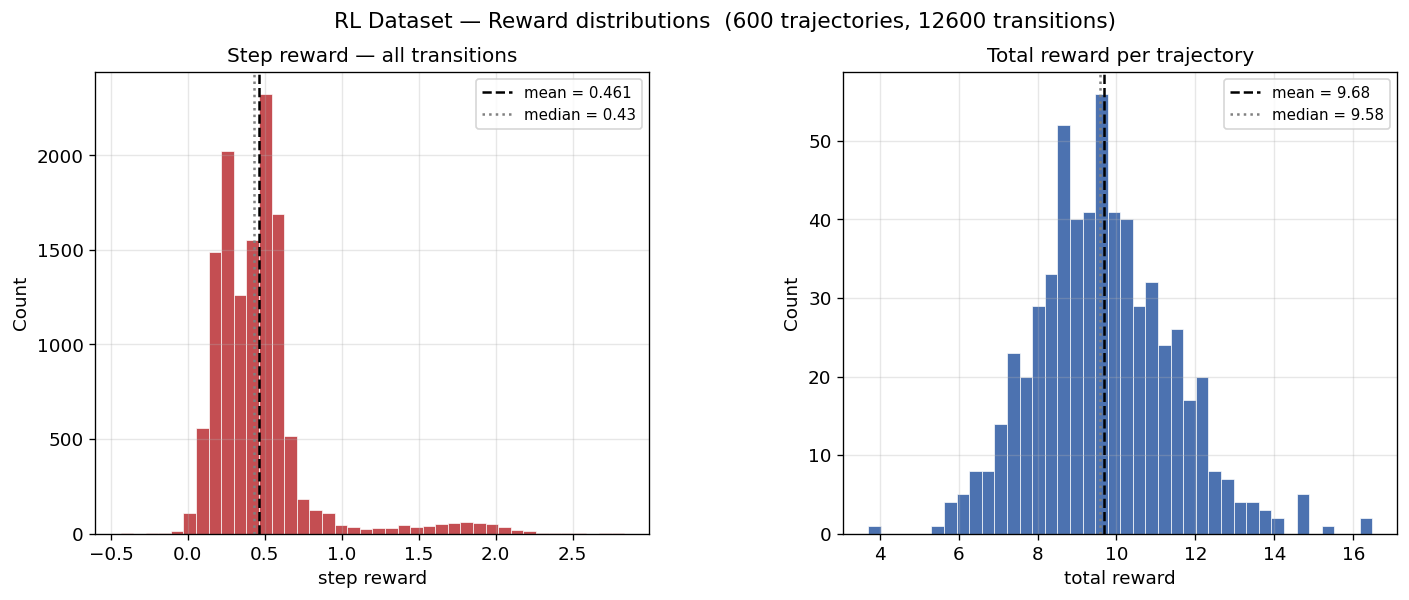

Saved → reward_histograms.png


In [13]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Config ──────────────────────────────────────────────────────────────────
DATASET_DIR = "test/"

# ── Load all JSON files ──────────────────────────────────────────────────────
step_rewards = []       # one entry per transition across all trajectories
total_rewards = []      # one entry per trajectory (sum of r over transitions)

files_ok = 0
for fname in sorted(os.listdir(DATASET_DIR)):
    if not fname.endswith(".json"):
        continue
    fpath = os.path.join(DATASET_DIR, fname)
    try:
        with open(fpath) as f:
            data = json.load(f)
        transitions = data["transitions"]
        rs = [t["r"] for t in transitions]
        step_rewards.extend(rs)
        total_rewards.append(sum(rs))
        files_ok += 1
    except Exception as e:
        print(f"Skipping {fname}: {e}")

step_rewards = np.array(step_rewards)
total_rewards = np.array(total_rewards)

print(f"Loaded {files_ok} trajectories, {len(step_rewards)} total transitions")

# ── Plot helper ──────────────────────────────────────────────────────────────
def hist_plot(ax, data, title, xlabel, color):
    d = data[~np.isnan(data)]
    if len(d) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title)
        return
    ax.hist(d, bins=40, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(np.mean(d), color='black', lw=1.5, linestyle='--',
               label=f'mean = {np.mean(d):.3g}')
    ax.axvline(np.median(d), color='gray', lw=1.5, linestyle=':',
               label=f'median = {np.median(d):.3g}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

hist_plot(ax1, step_rewards,  'Step reward — all transitions',       'step reward',      '#C44E52')
hist_plot(ax2, total_rewards, 'Total reward per trajectory',         'total reward',     '#4C72B0')

plt.suptitle(
    f'RL Dataset — Reward distributions  ({files_ok} trajectories, {len(step_rewards)} transitions)',
    fontsize=13
)
plt.tight_layout()
plt.savefig("reward_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reward_histograms.png")